# Electric Vehicle Population - Exploratory Data Analysis (EDA)
Before building the final dashboard, we need to understand the underlying patterns. We will analyze:
1. **Vehicle Range Distribution:** Are we seeing more long-range BEVs?
2. **Manufacturer Trends:** Which brands are dominating the 'Clean' category?
3. **Market Concentration:** Quantitative analysis of top cities.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the cleaned dataset
df_wa = pd.read_csv('../datasets/cleaned_dataset/Cleaned_EV_Population_Data.csv')
display(df_wa.head())

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Latitude,Longitude,CAFV_Eligible
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10,47.72201,-122.22901,1
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10,47.62759,-122.52100,1
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,47.57874,-122.30866,1
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10,46.94239,-122.60735,0
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10,47.37483,-122.19975,1


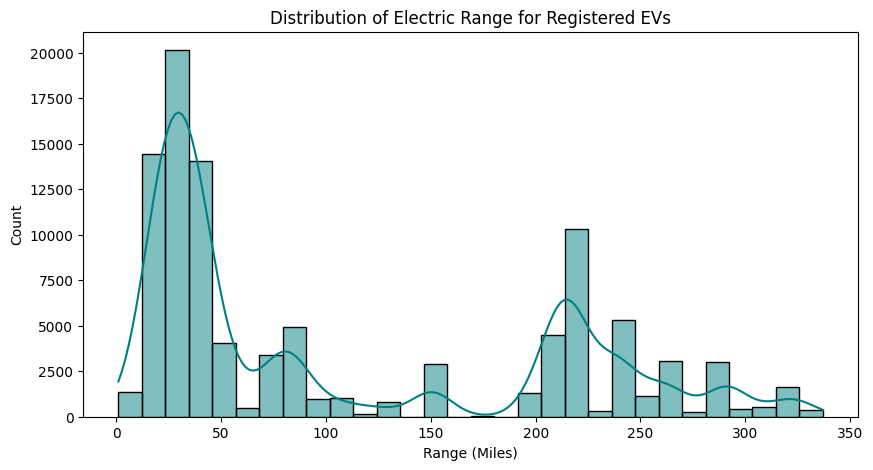

,count,mean,std,min,25%,50%,75%,max
Electric Vehicle Type,,,,,,,,
Battery Electric Vehicle (BEV),224606.0,40.480784,86.628504,0.0,0.0,0.0,0.0,337.0
Plug-in Hybrid Electric Vehicle (PHEV),55513.0,31.770342,13.946350,1.0,21.0,32.0,38.0,153.0


In [3]:
# 1. Distribution of Electric Range
plt.figure(figsize=(10, 5))
sns.histplot(df_wa[df_wa['Electric Range'] > 0]['Electric Range'], bins=30, kde=True, color='teal')
plt.title('Distribution of Electric Range for Registered EVs')
plt.xlabel('Range (Miles)')
plt.show()

# 2. Statistical Summary of Range by Vehicle Type
display(df_wa.groupby('Electric Vehicle Type')['Electric Range'].describe())

## Statistical Analysis: Adoption Growth
We will perform a year-over-year percentage growth calculation to quantify the 'surge' for the utility company.

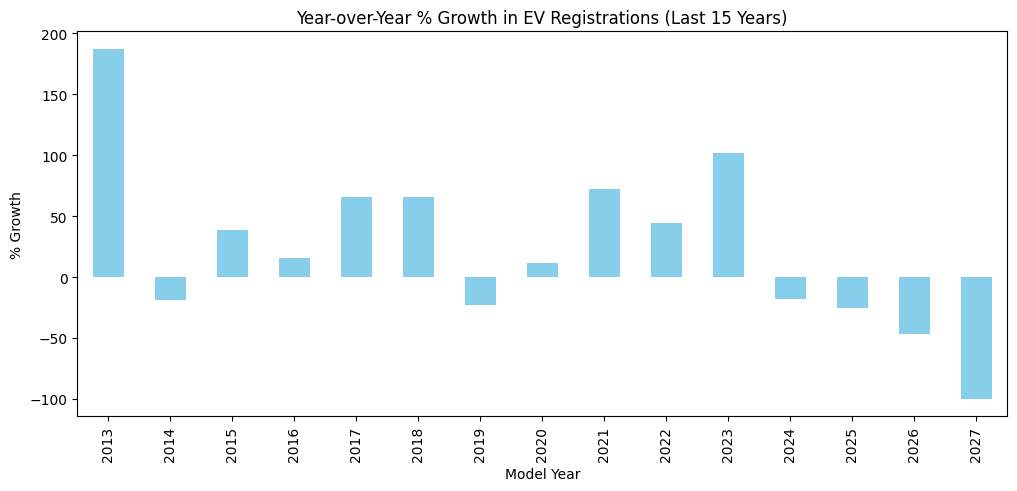

Average Growth Rate (Last 5 years): -17.61268330432447 %


In [4]:
# Calculate Yearly Growth Rates
yearly_counts = df_wa['Model Year'].value_counts().sort_index()
growth_stats = yearly_counts.pct_change() * 100

plt.figure(figsize=(12, 5))
growth_stats.tail(15).plot(kind='bar', color='skyblue')
plt.title('Year-over-Year % Growth in EV Registrations (Last 15 Years)')
plt.ylabel('% Growth')
plt.xlabel('Model Year')
plt.show()

print("Average Growth Rate (Last 5 years):", growth_stats.tail(5).mean(), "%")

## Correlation & Categorical Analysis
Identifying if CAFV eligibility correlates with specific manufacturers or vehicle types.

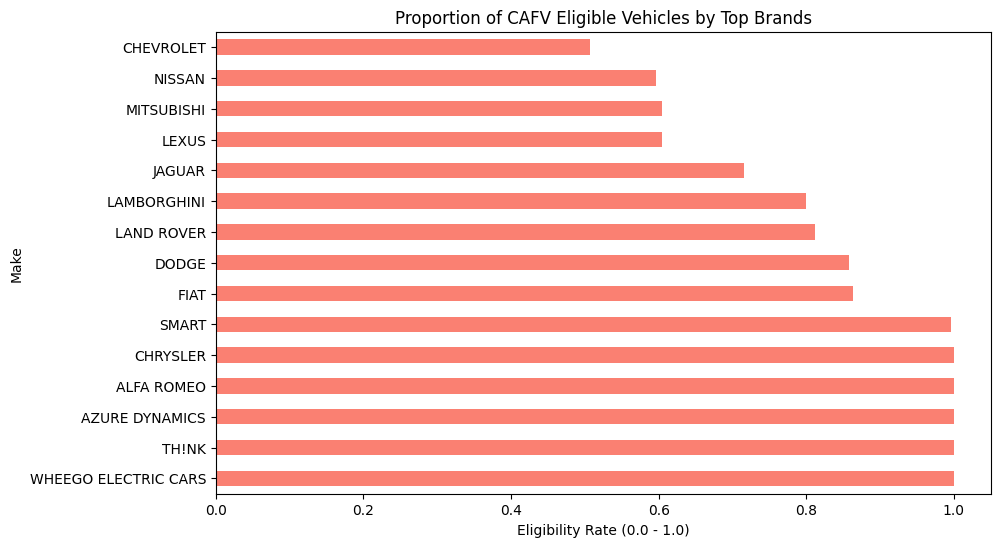

In [5]:
# Cross-tabulation of Brand vs Eligibility
eligibility_map = df_wa.groupby('Make')['CAFV_Eligible'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
eligibility_map.plot(kind='barh', color='salmon')
plt.title('Proportion of CAFV Eligible Vehicles by Top Brands')
plt.xlabel('Eligibility Rate (0.0 - 1.0)')
plt.show()